In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Settings
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
matches = pd.read_csv('../dataset/matches.csv')
deliveries = pd.read_csv('../dataset/deliveries.csv')

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)

Matches shape: (1095, 20)
Deliveries shape: (260920, 17)


In [3]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [5]:
print("=== MATCHES INFO ===")
print(matches.info())
print("\nMissing values in matches:")
print(matches.isnull().sum())

=== MATCHES INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  meth

In [6]:
seasons = sorted(matches['season'].unique())
print(f"Total seasons: {len(seasons)}")
print(f"Seasons covered: {seasons[0]} to {seasons[-1]}")
print(f"\nMatches per season:")
print(matches['season'].value_counts().sort_index())

Total seasons: 17
Seasons covered: 2007/08 to 2024

Matches per season:
season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
Name: count, dtype: int64


/var/folders/gd/kl2771sj2rndqpwqjlgn0fzc0000gn/T/ipykernel_16063/1677495964.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_counts.index, y=season_counts.values, palette='viridis')


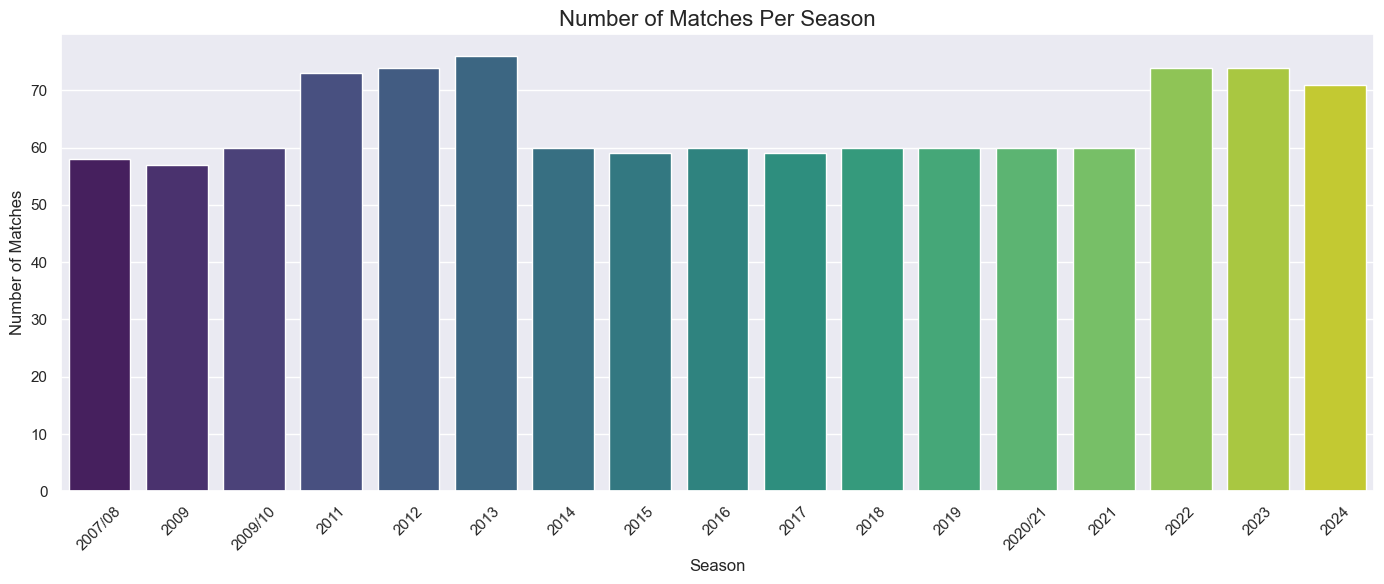

In [7]:
season_counts = matches['season'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
sns.barplot(x=season_counts.index, y=season_counts.values, palette='viridis')
plt.title('Number of Matches Per Season', fontsize=16)
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
all_teams = pd.concat([matches['team1'], matches['team2']]).unique()
print(f"Total unique teams: {len(all_teams)}")
print("\nAll teams:")
for t in sorted(all_teams):
    print(" -", t)

Total unique teams: 19

All teams:
 - Chennai Super Kings
 - Deccan Chargers
 - Delhi Capitals
 - Delhi Daredevils
 - Gujarat Lions
 - Gujarat Titans
 - Kings XI Punjab
 - Kochi Tuskers Kerala
 - Kolkata Knight Riders
 - Lucknow Super Giants
 - Mumbai Indians
 - Pune Warriors
 - Punjab Kings
 - Rajasthan Royals
 - Rising Pune Supergiant
 - Rising Pune Supergiants
 - Royal Challengers Bangalore
 - Royal Challengers Bengaluru
 - Sunrisers Hyderabad


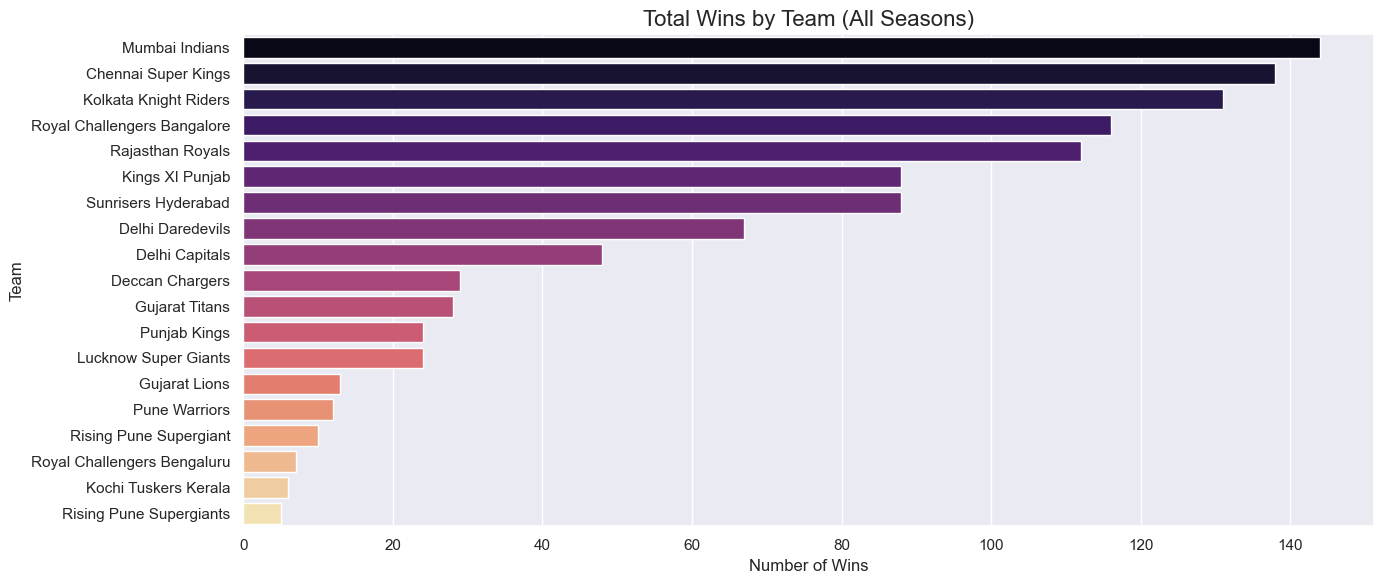

In [10]:
win_counts = matches['winner'].value_counts().dropna().reset_index()
win_counts.columns = ['team', 'wins']

plt.figure(figsize=(14, 6))
sns.barplot(data=win_counts, x='wins', y='team', hue='team', palette='magma', legend=False)
plt.title('Total Wins by Team (All Seasons)', fontsize=16)
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

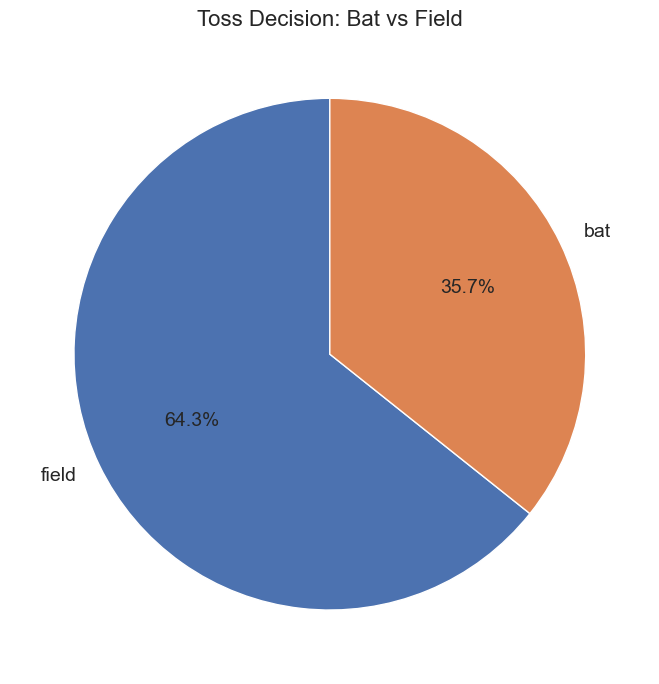

In [11]:
toss_decision = matches['toss_decision'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(toss_decision.values, labels=toss_decision.index, autopct='%1.1f%%',
        colors=['#4C72B0', '#DD8452'], startangle=90, textprops={'fontsize': 14})
plt.title('Toss Decision: Bat vs Field', fontsize=16)
plt.tight_layout()
plt.show()

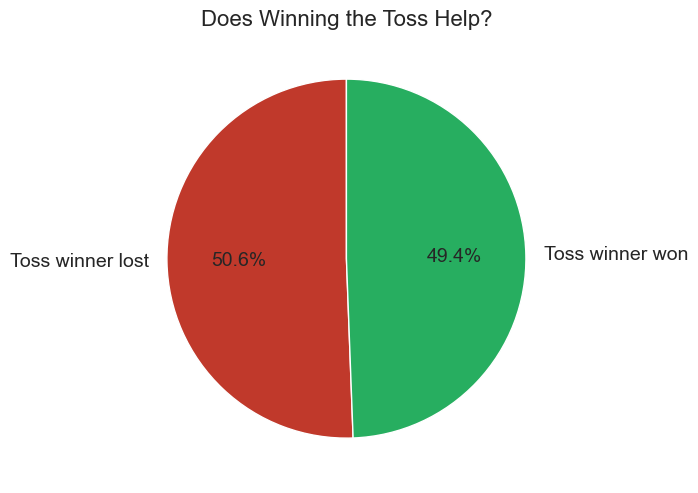

In [12]:
matches['toss_won_match'] = matches['toss_winner'] == matches['winner']
toss_impact = matches['toss_won_match'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(toss_impact.values, labels=['Toss winner lost', 'Toss winner won'],
        autopct='%1.1f%%', colors=['#c0392b', '#27ae60'], startangle=90, textprops={'fontsize': 14})
plt.title('Does Winning the Toss Help?', fontsize=16)
plt.tight_layout()
plt.show()

/var/folders/gd/kl2771sj2rndqpwqjlgn0fzc0000gn/T/ipykernel_16063/1935858845.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_venues.values, y=top_venues.index, palette='coolwarm')


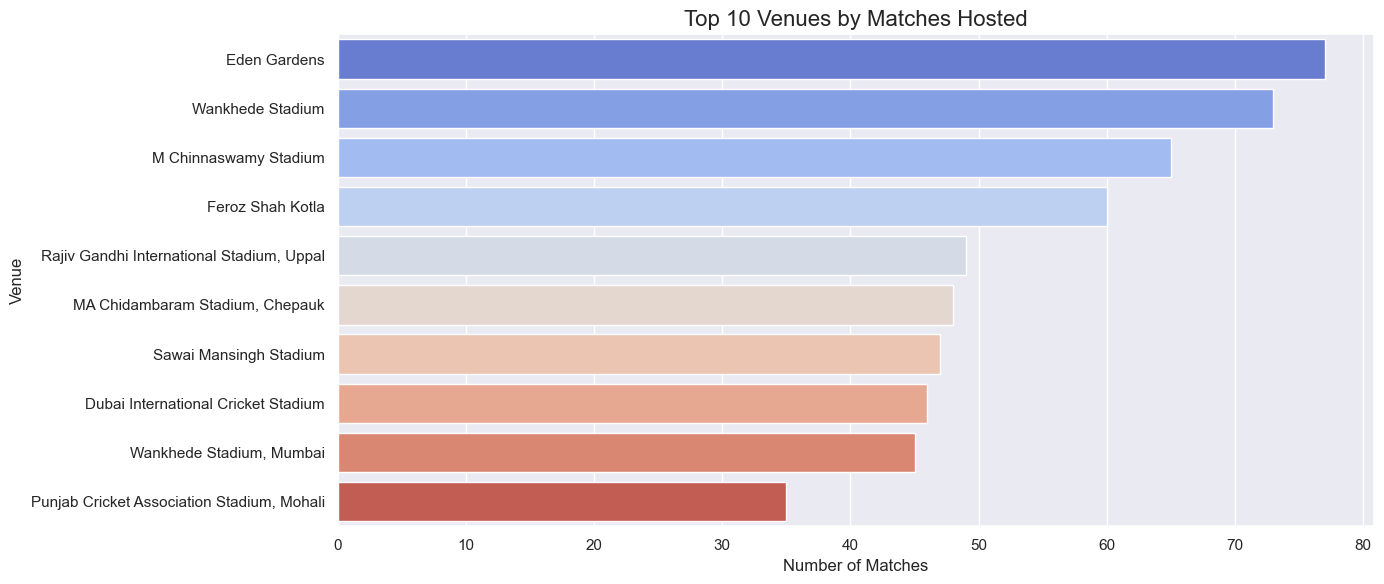

In [13]:
top_venues = matches['venue'].value_counts().head(10)

plt.figure(figsize=(14, 6))
sns.barplot(x=top_venues.values, y=top_venues.index, palette='coolwarm')
plt.title('Top 10 Venues by Matches Hosted', fontsize=16)
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

/var/folders/gd/kl2771sj2rndqpwqjlgn0fzc0000gn/T/ipykernel_16063/2459882452.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_potm.values, y=top_potm.index, palette='flare')


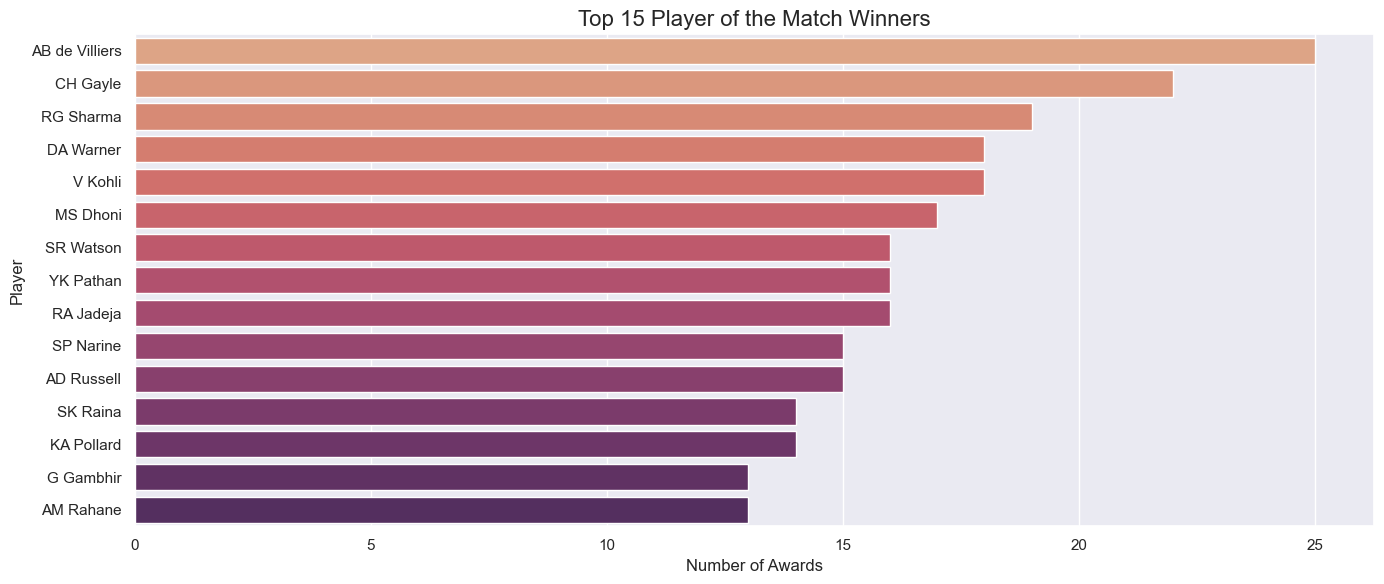

In [14]:
top_potm = matches['player_of_match'].value_counts().head(15)

plt.figure(figsize=(14, 6))
sns.barplot(x=top_potm.values, y=top_potm.index, palette='flare')
plt.title('Top 15 Player of the Match Winners', fontsize=16)
plt.xlabel('Number of Awards')
plt.ylabel('Player')
plt.tight_layout()
plt.show()

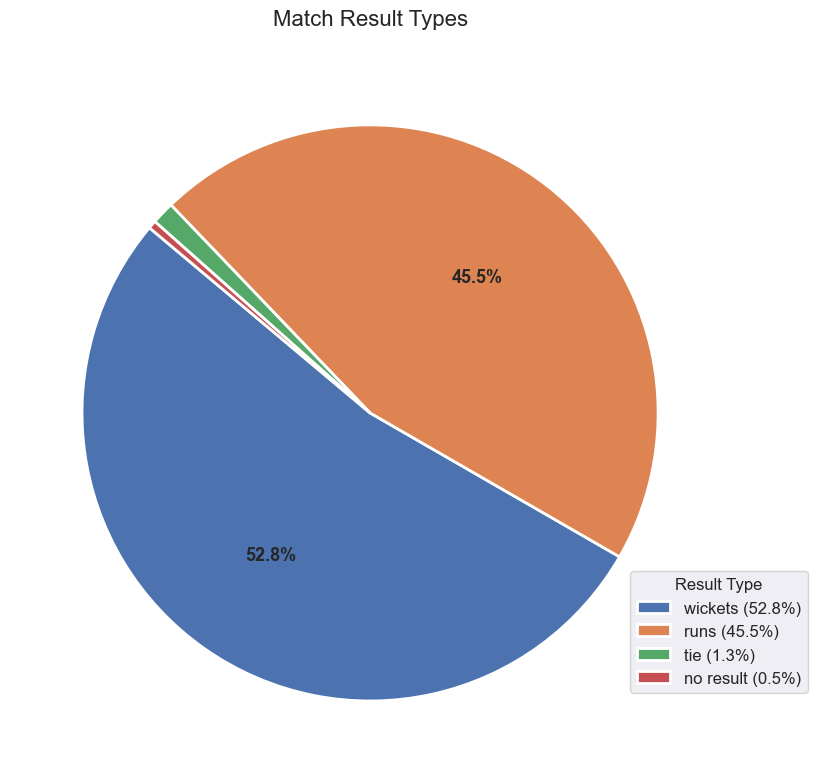

In [20]:
result_counts = matches['result'].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(
    result_counts.values,
    autopct=lambda pct: f'{pct:.1f}%' if pct > 5 else '',
    startangle=140,
    pctdistance=0.6,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_fontweight('bold')

plt.legend(wedges, [f'{label} ({val/result_counts.sum()*100:.1f}%)' 
           for label, val in zip(result_counts.index, result_counts.values)],
           title="Result Type",
           loc="lower left",
           bbox_to_anchor=(0.85, 0.1),
           fontsize=12)

plt.title('Match Result Types', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [21]:
print("=== EDA SUMMARY ===")
print(f"Total matches analysed: {len(matches)}")
print(f"Total deliveries bowled: {len(deliveries):,}")
print(f"Seasons covered: {matches['season'].nunique()}")
print(f"Unique teams: {pd.concat([matches['team1'], matches['team2']]).nunique()}")
print(f"Unique venues: {matches['venue'].nunique()}")
print(f"Most successful team: {matches['winner'].value_counts().idxmax()}")
print(f"Most Player of the Match awards: {matches['player_of_match'].value_counts().idxmax()}")
print(f"Toss winners who won the match: {matches['toss_won_match'].mean()*100:.1f}%")

=== EDA SUMMARY ===
Total matches analysed: 1095
Total deliveries bowled: 260,920
Seasons covered: 17
Unique teams: 19
Unique venues: 58
Most successful team: Mumbai Indians
Most Player of the Match awards: AB de Villiers
Toss winners who won the match: 50.6%
